# Differential expression analysis


You have run the nf-core/rnaseq pipeline and checked the first quality control metrics of your fastq files. This was, however, only the primary analysis and we want to take it further.

Due to the computational demand of the pipeline, you only ran the pipeline on two of the 16 samples in the study yesterday. We provide you an essential output of nf-core/rnaseq pipeline in the `data` folder: It contains the combined epression matrix as produced by Salmon, which provides transcript levels for each gene (rows) and each sample (columns).


We would now like to understand exactly the difference between the expression in our groups of mice. 
Which pipeline would you use for this?

*I now want to understand: <br> 1) Was the Gene Expression different? <br> 2) What genes/pathways were responsible for  the difference. <br> The pipeline to use would be differentialabundance → generates statistics on differential analysis*

Have a close look at the pipeline's "Usage" page on the [nf-core docs](nf-co.re). You will need to create a samplesheet (based on the column names in the provided matrix).

In [42]:
import pandas as pd


df = pd.read_csv("/home/nina/computational-workflows-2026/day_03/data/salmon.merged.gene_counts.tsv", sep="\t")
# preparing Sample sheet
samplesheet = pd.DataFrame({
    "sample": df.columns[2:]
})

samplesheet["Condition"] = samplesheet["sample"].str.replace(r"_\d+$", "", regex=True)

samplesheet.to_csv('sample_sheet.csv',  index=False)

# preparing Features table

features_df = df[["gene_id", "gene_name"]].copy()
features_df.to_csv('features.csv',  index=False)

# preparing matrix table
 
matrix_df = df.drop("gene_name", axis=1)
matrix_df.to_csv('matrix.csv',  index=False)

# preparing lengths table

lengths_df = pd.read_csv("/home/nina/computational-workflows-2026/day_03/data/rnaseq-out-small/star_salmon/salmon.merged.gene_lengths.tsv", sep="\t")

sample_map = {
    "Nac_oxy_1" : "Sham_oxy_1",
    "Nac_oxy_2" : "SNI_oxy_1",
    "Nac_oxy_3" : "SNI_oxy_2",
    "Nac_oxy_4" : "Sham_oxy_2",
    "Nac_oxy_5" : "Sham_oxy_3",
    "Nac_oxy_6" : "SNI_oxy_3",
    "Nac_oxy_7" : "SNI_oxy_4",
    "Nac_oxy_8" : "Sham_oxy_4",
    "Nac_Sal_1" : "SNI_Sal_1",
    "Nac_Sal_2" : "Sham_Sal_1",
    "Nac_Sal_3" : "SNI_Sal_2",
    "Nac_Sal_4" : "Sham_Sal_2",
    "Nac_Sal_5" : "SNI_Sal_3",
    "Nac_Sal_6" : "Sham_Sal_3",
    "Nac_Sal_7" : "SNI_Sal_4",
    "Nac_Sal_8" : "Sham_Sal_4"
}

lengths_df = lengths_df.rename(columns=sample_map)

lengths_df.to_csv('lengths_matrix.csv',  index=False)

 # checking if sample sheets are correct
print(f"lengths:  {lengths_df.head()}")
print(f"matrix: {matrix_df.head()}")
print(f"features: {features_df.head()}")
print("Sample Sheet: {samplesheet.head()}")


lengths:                gene_id gene_name   Sham_oxy_1    SNI_oxy_1    SNI_oxy_2  \
0  ENSMUSG00000000001     Gnai3  3124.407000  3107.183000  3067.475000   
1  ENSMUSG00000000003      Pbsn   630.321219   630.321219   630.321219   
2  ENSMUSG00000000028     Cdc45  1609.407000  1988.183000  1829.977092   
3  ENSMUSG00000000031       H19  1131.832093  1131.832093  1131.832093   
4  ENSMUSG00000000037     Scml2  3412.407000  4687.183000  4498.181260   

    Sham_oxy_2   Sham_oxy_3    SNI_oxy_3    SNI_oxy_4   Sham_oxy_4  \
0  3081.014000  3081.149000  3072.785000  3104.240000  3101.951000   
1   630.321219   630.321219   630.321219   630.321219   630.321219   
2  1962.014000  1962.149000  1557.785000  1985.240000  1586.951000   
3  1131.832093  1131.832093  1131.832093  1131.832093  1131.832093   
4  4661.014000  4661.149000  4652.785000  3756.754236  4060.722161   

     SNI_Sal_1   Sham_Sal_1    SNI_Sal_2   Sham_Sal_2    SNI_Sal_3  \
0  3096.872000  3111.209000  3091.812000  3072.957000 

Please paste here the command you used. You may need to inspect the provided expression matrix more closely and create additional files, like a samplesheet (based on the column names) or a contrast file (there happens to also be one in `data/` that you can use).

In [44]:
!nextflow run nf-core/differentialabundance \
    -r 2.0.0 \
    -profile docker \
    -c nextflow.config \
    --input sample_sheet.csv \
    --contrasts contrasts.csv \
    --matrix matrix.csv \
    --feature_length_matrix lengths_matrix.csv \
    --features features.csv \
    --outdir differentialabundance_output


 N E X T F L O W   ~  version 26.04.6

Launching `https://github.com/nf-core/differentialabundance` [agitated_monod] revision: 30ed7741fc [2.0.0]

WARN: Unrecognized config option 'validation.defaultIgnoreParams'
WARN: Unrecognized config option 'validation.monochromeLogs'

------------------------------------------------------
                                        ,--./,-.
        ___     __   __   __   ___     /,-._.--~'
  |\ | |__  __ /  ` /  \ |__) |__         }  {
  | \| |       \__, \__/ |  \ |___     \`-._,-`-,
                                        `._,._,'
  nf-core/differentialabundance 2.0.0
------------------------------------------------------

[base] Input/output options
  input                       : sample_sheet.csv
  contrasts                   : contrasts.csv
  outdir                      : differentialabundance_output

[base] Abundance values
  matrix                      : matrix.csv
  feature_length_matrix       : lengths_matrix.csv

[base] Features options
  

Explain all the parameters you set and why you set them in this way. If you used or created additional files as input, explain what they are used for.

*-r 2.0.0  = specifies the version of the pipeline I want to use. Ensures pipeline runs with a fixed version<br><br>
-profile docker  = defining that i want to run the pipeline using the Docker profile <br><br>
-c nextflow.config = nextflow configuration file used for this analysis. The file contains configuration setting for running the pipeline optimized for my device <br><br>
--input sample_sheet.csv = the sample input sheet, with experimental condition and the sample name <br><br>
--contrasts contrasts.csv = contains the contrast datasheet, which determines which experimental groups should be compared against one another, in this case I included comparsions between all experimental groups, as I was interested in seeing the differences. The main comparsion, was between the Sham_Sal vs Sham_oxy, and the SNI_Sal vs SNI_oxy groups though.<br><br>
--matrix matrix.csv = specifies the matrix table. which includes for each sample the gene id and corresponding read count.<br> <br>
--feature_length_matrix lengths_matrix.csv = the feature length matrix contains the lengths of the genes, this is necessary to normalize the counts.<br><br>
--features features.csv = is necessary to map the gene ids to the gene names <br> <br>
--outdir differentialabundance_output = output folder directory*


What were the outputs of the pipeline?

*The pipeline outputs multiple folders, with the results from the differential abundance analysis such as tables and plots. As well as an Nextflow workflow report. The most interesting is the differential abundance report html, this report summarizes the ouputs of the differential gene analysis, with graphs and tables. <br> 
For our run, the output includes count filtering statistics, exploratory analysis (such as PCA and Heatmaps) and the differential analysis (such as Box plots of the expression levels and Vulcano plots) of the groups specified in the contrast table. <br>* 

Would you exclude any samples? If yes, which and why?

*During the outlier detection, no outlier was found. But looking at the PCA plots, the SNI_Sal group has a much higher variance within its condition, then when compared to the other conditions. Specifically SNI_Sal_2 and SNI_Sal_4 stand out. Looking at the PCA table it appears as though as though all experimental groups have a similar expression profile (as the samples are clustering together), but only these two samples appear rather far away from the cluster. In the boxplots showing the distribution of expression levels for the top 10 genes, we can also see that these two samples stand out quite a bit, causing a distortion of the data. These two samples might have been contaminated or might have some other experimental error, therefore I would not include these two samples.* 

How many genes were differentially expressed in each contrast? Does this confirm what the paper mentions?

|                                       | up | down | 
|---------------------------------------|----|------| 
| Sham_oxy versus Sham_Sal in Condition | 7  | 0    |  
| SNI_oxy versus SNI_Sal in Condition   | 0  | 17   |   
| Sham_oxy versus SNI_Sal in Condition  | 2  | 18   |   
| SNI_oxy versus Sham_Sal in Condition  | 1  | 0    |

(p- values adjusted with Benjamin Hochberg method to reduce false positives. p-value <= 0.1, log2 fold => |0|) <br> <br>
*→ This does not confirm what the paper mentioned (Paper used a P < 0.05, and log2 fold change >= |0.05|). We found a substantially lower number of differentially expressed gene, then the paper reported. It should be of note, that our pipeline also filtered out a lot of genes due to low abundance. We did not successfully replciate their analysis.*


The paper mentions differentially expressed genes in three brain regions : the NAc, mPFC and VTA. Briefly explain what these 3 regions are.

- *NAc(Nucleus accumbens): region in the basal forebrain, responsible for processing motivation, reward, aversion and reinforcement learning*
- *VTA(Ventral Tegmental Area): mid brain, houses dopamine production*
- *mPFC(Prefrontal cortex): part of the frontal lobe, important/used for working memory, important for addiction, as involved in processes such as focus, control, making decisions* <br>


Is there anyway from the paper and the material and methods for us to know which genes are included in these regions?

*→ paper does not give a whole table or explanation of what genes are included in the brain regions. Making it hard to understand what genes were included in the analysis, this makes it hard to replicate their results.*

Once you have your list of differentially expressed genes, do you think just communicating those to the biologists would be sufficient? What does the publication state?

*No, that would not suffice. We further need to determine the biological processes and pathways these genes are involved in to understand the significance of the differential expression. In the paper, the author do go into the pathways and cell function these genes are involved in, rather than listing specific genes.*

Please reproduce the Venn Diagram from Figure 3, not taking into account the brain regions but just the contrasts mentionned.

/home/nina/miniconda3/envs/ComputWorkflows/lib/python3.13/site-packages/matplotlib_venn/layout/venn3/pairwise.py:169: UserWarning: Bad circle positioning.
  warnings.warn("Bad circle positioning.")


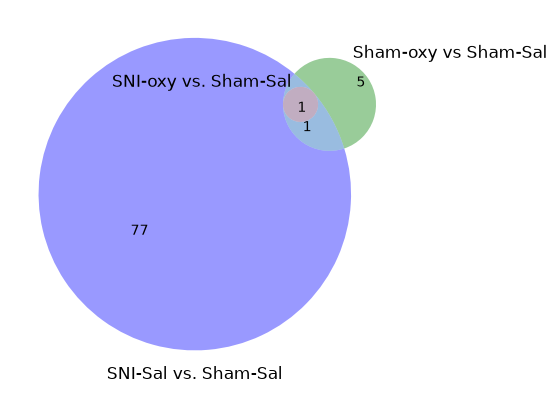

In [47]:
from matplotlib import pyplot as plt
from matplotlib_venn import venn3, venn3_circles
import pandas as pd

snioxy_shamsal_df = pd.read_csv("/home/nina/computational-workflows-2026/day_03/differentialabundance_output/tables/differential/contrasts/condition_control_treated_Sham_sal_vs_sni_oxy_study.deseq2.results_filtered.tsv", sep="\t")
shamoxy_shamsal = pd.read_csv("/home/nina/computational-workflows-2026/day_03/differentialabundance_output/tables/differential/contrasts/condition_control_treated_test_study.deseq2.results_filtered.tsv", sep="\t")
snisal_shamsal = pd.read_csv("/home/nina/computational-workflows-2026/day_03/differentialabundance_output/tables/differential/contrasts/condition_control_treated_sni_sal_vs_sham_sal_study.deseq2.results_filtered.tsv", sep="\t")


venn3([set(snioxy_shamsal_df["gene_id"]), set(shamoxy_shamsal["gene_id"]), set(snisal_shamsal["gene_id"])], ('SNI-oxy vs. Sham-Sal', 'Sham-oxy vs Sham-Sal', 'SNI-Sal vs. Sham-Sal'))
plt.show()


*Reproducing the Venn diagramm is impossible. Due to the substantially smaller amount of differentialy expressed genes, that we found the Venn Diagramm is heavily distorted. the SNI-oxy vs Sham-Sal group shares its one differentially expressed gene with both the sham-oxy vs sham-sal and the sni-sal vs sham-sal group. the sni-sal vs sham-sal differentially expressed group also has in total much more differentially expressed genes than any of the other groups.* 